# MATERIAL

ne =  2.1463557810023133
no =  2.229080611296175
eps_e =  4.606843138642049
eps_o =  4.96880037165653
ne =  [2.315266894439615, 2.313957321796871, 2.312662530344611, 2.3113822837204636, 2.3101163504888222, 2.3088645040136186, 2.3076265223350227, 2.3064021880499284, 2.305191288196083, 2.303993614139739, 2.302808961466697, 2.301637129876632, 2.300477923080568, 2.2993311487014148, 2.298196618177445, 2.2970741466686144, 2.2959635529656315, 2.2948646594016773, 2.2937772917666903, 2.2927012792241257, 2.2916364542301104, 2.2905826524549076, 2.2895397127066204, 2.2885074768570584, 2.2874857897696907, 2.2864744992296258, 2.285473455875547, 2.284482513133539, 2.283501527152746, 2.2825303567428055, 2.281568863312995, 2.2806169108130394, 2.2796743656755325, 2.2787410967599078, 2.277816975297923, 2.2769018748406067, 2.2759956712066187, 2.275098242431982, 2.2742094687211467, 2.27332923239934, 2.2724574178661685, 2.2715939115504264, 2.2707386018660864, 2.269891379169422, 2.269052135717236, 2.26822076

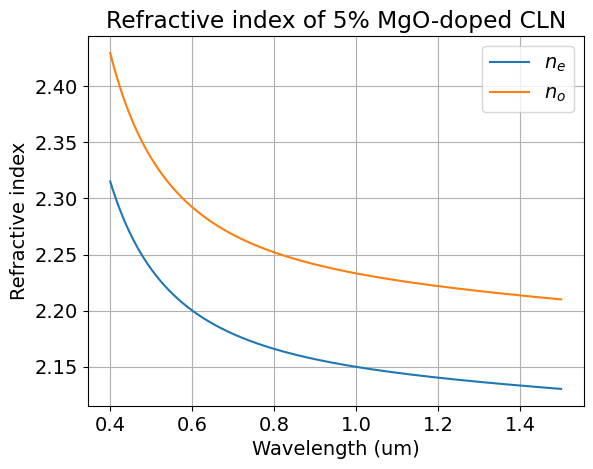

In [1]:
import numpy as np  
import matplotlib.pyplot as plt
# 5% Mg doped CLN
def get_n2i(lam, T, a, b): 
    lam = lam *1e6 # convert to um
    f = get_f(T)
    b = [bb* f for bb in b]
    n2 = a[0] + b[0] + (a[1]+b[1])/(lam**2 - (a[2]+b[2])**2) + (a[3]+b[3])/(lam**2 - (a[4]**2)) - a[5]*lam**2
    return n2

ae = [05.756, 0.0983, 0.2020,189.32,12.52, 1.32e-2 ]
ao = [5.653, 0.1185, 0.2091, 89.61, 10.85, 1.97e-2]
be = [2.86e-6, 4.7e-8, 6.113e-8, 1.516e-8]
bo = [7.941e-7, 3.134e-8, -4.641e-9, -2.188e-60]

def get_f(T):
    return (T-24.5)*(T+570.82)

lam0 = 1064e-9
n2e = get_n2i(lam0, 20, ae, be)
n2o = get_n2i(lam0, 20, ao, bo)

eps_e = n2e
eps_o = n2o

ne = np.sqrt(eps_e)
no = np.sqrt(eps_o)
print("ne = ", ne)
print("no = ", no)
print("eps_e = ", eps_e)
print("eps_o = ", eps_o)

nes =[]
nos = []
lams = np.linspace(400e-9, 1500e-9, 1000)
for lam in lams:
    n2e = get_n2i(lam, 20, ae, be)
    n2o = get_n2i(lam, 20, ao, bo)
    ne = np.sqrt(n2e)
    no = np.sqrt(n2o)

    nes.append(ne)
    nos.append(no)


plt.rcParams["font.size"] = 14  
plt.plot(lams*1e6, nes, label='$n_e$')
plt.plot(lams*1e6, nos, label='$n_o$')
print("ne = ", nes, "no = ", nos)
plt.xlabel('Wavelength (um)')
plt.ylabel('Refractive index')
plt.title('Refractive index of 5% MgO-doped CLN')
plt.grid()
plt.legend()

# CONFIG

In [170]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from src.photonic_crystal_maker import (Material, Geometry, PhotonicCrystal, 
                                        ScriptParam, ScriptParamVector3, BaseDielectricDistribution,
                                        HexagonalLattice, SquareLattice)
import meep as mp
from src.mpb_configurator import *
from src.mpi_differential_evolution import MPIdeOptimizator
from src.simulation_handler import LSFJobConfiguration, MPBDataOptions, Simulation
from src.optimization_data_analyzer import OptimizationDataAnalyzer
from src.simulation_viewer import SimulationViewer

import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors

eps = (eps_o, eps_o, eps_e)


LN = Material(epsilon = eps)
print("Epsilon of LiNbO3: ", LN.to_scheme())
air = Material(epsilon = 1)

## Simulation Name: 
name = "mirror"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice

lattice_2D = HexagonalLattice()
lattice_slab = HexagonalLattice(supercell_height= 4)

k_points = lattice_2D.get_high_symmetry_k_points(centered_in_gamma=False)
print(k_points)


center = mp.Vector3(0,0,0)


geom_2D = BaseDielectricDistribution(eps_bulk = eps).make_C3v_monoatomic()
geom_slab = BaseDielectricDistribution(eps_bulk = eps, height_slab=0.5).make_C3v_monoatomic()


photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=geom_2D)
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=geom_slab)

## Define the simulation
configuration_options = dict(
    resolution = 32, 
    num_bands=5,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 10,
)

configuration_options_optimization = dict(
    resolution = 32, 
    num_bands=5,
    k_points = [mp.Vector3(0,0,0)],
    
)
    
configuration_options_sweep = dict( 
    resolution = 32,
    num_bands=30,
    k_points=[mp.Vector3(0,0,0)],
)

mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven", "zodd"], **configuration_options)
mpb_configuration_2D_opt = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm" ], **configuration_options_optimization)
mpb_configuration_slab_opt = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_optimization)
mpb_configuration_2D_sweep = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options_sweep)

script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)
script_2D_opt = mpb_configuration_2D_opt.get_scheme_config(join_newline=True)
script_slab_opt = mpb_configuration_slab_opt.get_scheme_config(join_newline=True)
script_2D_sweep = mpb_configuration_2D_sweep.get_scheme_config(join_newline=True)



name_2D = name  + "_2D"
name_slab = name + "_slab"
name_2D_opt = name + "_2D_opt"
name_slab_opt = name + "_slab_opt"
name_2D_sweep = name + "_2D_sweep"

data_rooth = "/work3/s232699/phc_nzi/LiNb/ooe_mirror"

simulation_2D = Simulation(
    simulation_name=name_2D,
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D)
    )

simulation_2D_opt = Simulation(
    simulation_name=name_2D_opt,
    script = script_2D_opt,
    directory= os.path.join(data_rooth, name_2D_opt)
    )

simulation_slab = Simulation(
    simulation_name=name_slab,
    script = script_slab,
    directory= os.path.join(data_rooth, name_slab)
    )


simulation_slab_opt = Simulation(
    simulation_name=name_slab_opt,
    script = script_slab_opt,
    directory= os.path.join(data_rooth, name_slab_opt)  
    )


simulation_2D_sweep = Simulation(
    simulation_name=name_2D_sweep,
    script = script_2D_sweep,
    directory= os.path.join(data_rooth, name_2D_sweep)
    )


#absolute_path_home = "/zhome/2f/7/202918/phc_nzi"

numproc= 32
pop = numproc // 2
lsf_config = LSFJobConfiguration(num_processors=numproc, span_option="block", span_value=8, queue="fotonano")


Epsilon of LiNbO3:  (make dielectric-anisotropic (epsilon-diag (vector3 4.96880037165653 4.96880037165653 4.606843138642049)))
{'k_points_values': [Vector3<0.0, 0.0, 0.0>, Vector3<-0.3333333333333333, 0.3333333333333333, 0.0>, Vector3<0.0, 0.5, 0.0>, Vector3<0.0, 0.0, 0.0>], 'k_points_labels': ['$\\Gamma$', 'K', 'M', '$\\Gamma$']}
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)']


# 2D

## Unoptimized

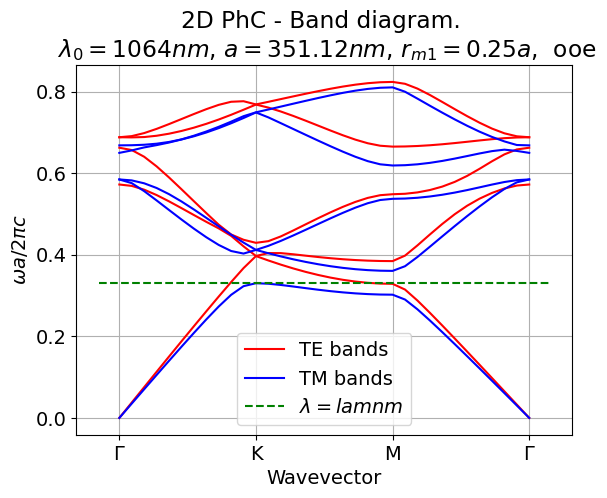

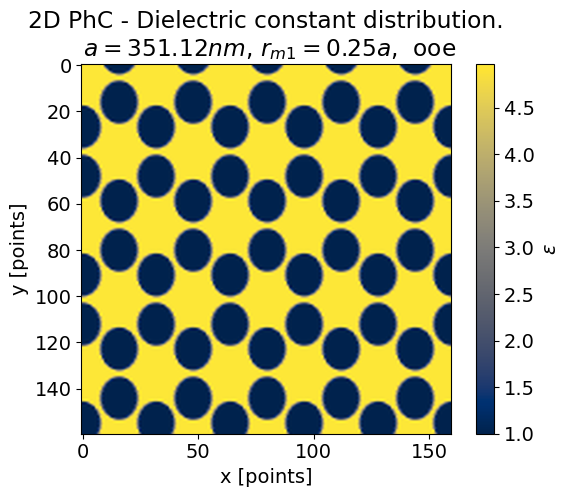

In [171]:
r_m1 = 0.25
simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = r_m1), mpi = True)
viewer_2D = SimulationViewer(simulation_2D) 
opt = MPBDataOptions(rectify=True, periods= 5, transpose=True,)

plt.figure()    
viewer_2D.plot_band_diagram("te", k_points_path=k_points, color = "red")
viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
lam = 1064
wt = 0.33
aa = wt*lam
xlim = plt.xlim()
plt.plot(xlim, [wt, wt], color = "g", linestyle = "--", label = "$\lambda = {lam} nm$")
plt.ylabel("$\omega a/2\pi c$")
plt.legend()
plt.title(f"2D PhC - Band diagram. \n $\lambda_0 = {lam}nm $, $a={aa:.2f} nm$, $r_{{m1}} = {r_m1:.2f}a$,  ooe")
viewer_2D.show()

viewer_2D.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt)
plt.title(f"2D PhC - Dielectric constant distribution.\n $a={aa:.2f} nm$, $r_{{m1}} = {r_m1:.2f}a$,  ooe")
plt.xlabel("x [points]")
plt.ylabel("y [points]")
plt.gca().set_aspect('equal', adjustable='box')
viewer_2D.show()

#equal aspect ratio 



#viewer_2D.plot_field_2d(1, 6, "h", "z", "te", False, np.abs) 


In [154]:
print(simulation_2D_sweep.script)

(set! num-bands 30)
(set! resolution 32)
(set! k-points (list (vector3 0.0 0.0 0.0)))
(set! k-points (interpolate 4 k-points))
(define-param h 1e+20)
(define-param r1 0.1)
(set! geometry-lattice (make lattice (size 1 1 no-size) (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (size (vector3 1 1 h))
  (center (vector3 0.0 0.0 0.0))
  (material (make dielectric-anisotropic (epsilon-diag (vector3 4.96880037165653 4.96880037165653 4.606843138642049)))))
 (make cylinder (radius r1)
  (height h)
  (center (vector3 0.0 0.0 0.0))
  (material (make dielectric (epsilon 1))))
 (make cylinder (radius r1)
  (height h)
  (center (vector3 0.3333333333333333 0.3333333333333333 0.0))
  (material (make dielectric (epsilon 1))))
))

(define (output-nonbloch-efield which-band)
    (get-efield which-band)
    (cvector-field-nonbloch! cur-field)
    (output-field-to-file -1 (string-append (get-filename-prefix)"e."))
)


(defi

In [183]:
defect_script = f"""
; A line-defect waveguide in a 2d triangular lattice of dielectric
; rods (c.f. tri-rods.ctl), formed by a row of missing rods along the
; "x" direction.  (Here, "x" and "y" refer to the first and second
; basis directions.)  This structure supports a single guided band
; within the band gap, much like the analogous waveguide in a square
; lattice of rods (see "Photonic Crystals" by Joannopoulos et al.).

(define-param h infinity)
(define eps_LN (epsilon-diag {eps[0]} {eps[1]} {eps[2]})) ; the dielectric constant of the slab
(define-param r1 0.2) ; the rod radius in the bulk crystal
(define-param r2 0.3) ; the rod radius in the defect
(define-param supercell_y 1) ; the (odd) number of lateral supercell periods
(define-param supercell_x 8) ; the number of supercell periods in the x direction
(define-param supercell_z no-size) ; the size of the supercell in the y direction
(define LN (make dielectric-anisotropic eps_LN)) ; the dielectric constant of the slab
(set! geometry-lattice (make lattice 
			 (basis1 1 0)
			 (basis2 0.5 (/ (sqrt 3) 2))
			 (size supercell_x supercell_y supercell_z)))
             
(define LN_block (make block
                     (size (vector3 infinity infinity h))
                     (center (vector3 0.0 0.0 0.0))
                     (material LN)))


(define hole1 (make cylinder (radius r2)
                              (height h)
                              (center (vector3 1/3 1/3 0.0))
                              (material air)))
(define hole2 (make cylinder (radius r2)
                              (height h)
                              (center (vector3 2/3 2/3 0.0))
                              (material air)))


(define hole1_filled (make cylinder (radius r2)
                              (height h)
                              (center (vector3 1/3 1/3 0.0))
                              (material LN)))
(define hole2_filled (make cylinder (radius r2)
                              (height h)
                              (center (vector3 2/3 2/3 0.0))
                              (material LN)))



(set! geometry (list 
           LN_block
          
            hole1
            hole2
))

(set! geometry 
      (append
       ; duplicate the bulk crystal rods over the supercell:
       
       (geometric-objects-lattice-duplicates geometry)

       ; add a rod of LN, to erase a row of rods and form a waveguide:
       (list 
            

               (make block
                         (size (vector3 1 1 h))
                         (center (vector3 0.0 0.0 0.0))
                         (material LN))

       )
))

(define Gamma (vector3 0 0 0))
(define K' (cartesian->reciprocal (vector3 0.5 0 0))) ; edge of Brillouin zone.
(define-param interpolation_factor 10) ; number of k-points between Gamma and K'
(set! k-points (interpolate interpolation_factor (list Gamma K')))

; the bigger the supercell, the more bands you need to compute to get
; to the defect modes (the lowest band is "folded" supercell-y times):
(define-param extra_bands 5) ; number of extra bands to compute above the gap
(set! num-bands (+ (max supercell_y supercell_x) extra_bands))

(set-param! resolution 32)

; Compute the TM modes, outputting the Ez field in the *middle* of the
; band.  (In general, the guided mode in such an air defect may have
; exited the gap by the time it reaches the edge of the Brillouin
; zone at K'.)
(run-tm fix-efield-phase output-efield-z)
"""

In [206]:
simulation_line_defect = Simulation(
    simulation_name=name_2D + "_defect",
    script = defect_script,
    directory= os.path.join(data_rooth, name_2D + "_defect")
    )

interpolation_factor = 10
simulation_line_defect.run_hpc(mpb_command_line_params=dict(
                                                            r2 = r_m1, 
                                                            supercell_x = 6, 
                                                            supercell_y = 1,
                                                            interpolation_factor=interpolation_factor,
                                                            extra_bands = 6,
                                                            ), 
                            mpi = True)


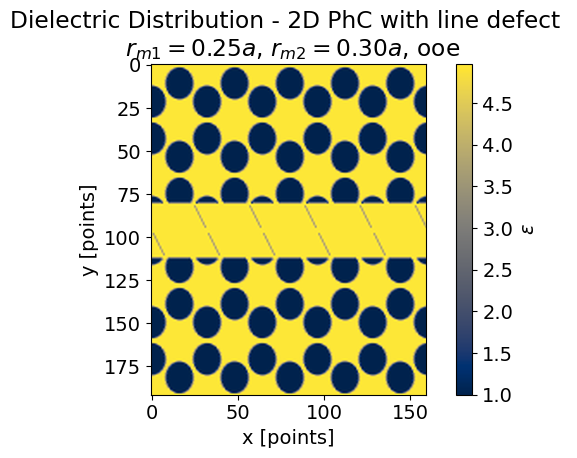

,k index,k1,k2,k3,kmag/2pi,tm band 1,tm band 2,tm band 3,tm band 4,tm band 5,tm band 6,tm band 7,tm band 8,tm band 9,tm band 10,tm band 11,tm band 12
0,1,0.000000,0.000000,0,0.000000,0.000000,0.103923,0.110089,0.211563,0.213060,0.297649,0.334909,0.415204,0.431094,0.495475,0.502484,0.513505
1,2,0.272727,0.022727,0,0.045455,0.025243,0.085963,0.129526,0.191541,0.233562,0.288908,0.343043,0.403777,0.443412,0.487894,0.496603,0.511379
2,3,0.545455,0.045455,0,0.090909,0.050272,0.068377,0.152311,0.171817,0.254857,0.272218,0.355700,0.390864,0.460836,0.475232,0.482486,0.520785
3,4,0.818182,0.068182,0,0.136364,0.055775,0.076096,0.152623,0.176359,0.254081,0.275591,0.355589,0.392921,0.458513,0.468621,0.481662,0.523395
4,5,1.090910,0.090909,0,0.181818,0.053985,0.100934,0.136274,0.199814,0.236105,0.293920,0.344896,0.407897,0.442158,0.459158,0.497025,0.516007
5,6,1.363640,0.113636,0,0.227273,0.062983,0.120220,0.128271,0.218809,0.223491,0.302644,0.340907,0.418328,0.432834,0.449642,0.504809,0.508689
6,7,1.636360,0.136364,0,0.272727,0.079086,0.112153,0.151577,0.203064,0.246720,0.295160,0.351722,0.407386,0.435961,0.450085,0.489247,0.497016
7,8,1.909090,0.159091,0,0.318182,0.097687,0.108852,0.175921,0.189345,0.269467,0.281596,0.364235,0.398046,0.427014,0.462526,0.474326,0.485457
8,9,2.181820,0.181818,0,0.363636,0.106500,0.122780,0.176857,0.201288,0.267308,0.290909,0.364132,0.402317,0.417732,0.456760,0.472775,0.476089
9,10,2.454550,0.204545,0,0.409091,0.113554,0.144642,0.168490,0.225460,0.253736,0.308704,0.357198,0.403722,0.418981,0.444374,0.467366,0.476045


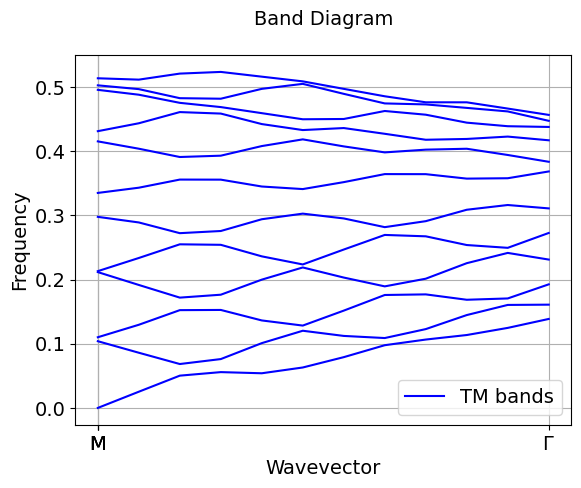

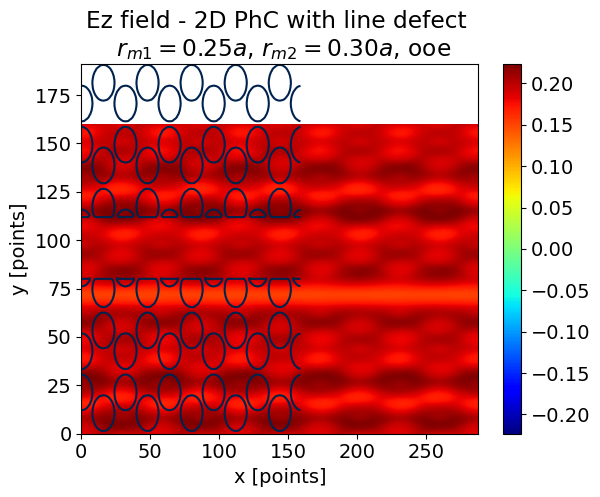

In [210]:

viewer_line_defect = SimulationViewer(simulation_line_defect)
conversion_options = MPBDataOptions(rectify=True, periods= (5,1,1), transpose=True)
viewer_line_defect.plot_epsilon_2d(conversion_options=conversion_options)
plt.title(f"Dielectric Distribution - 2D PhC with line defect \n $r_{{m1}} = {r_m1:.2f}a$, $r_{{m2}} = {r_m2:.2f}a$, ooe")
plt.xlabel("x [points]")
plt.ylabel("y [points]")
plt.tight_layout()
plt.show()

plt.figure()

viewer_line_defect.plot_band_diagram("tm", k_points_path=k_points, color = "blue")

df = simulation_line_defect.load_frequency_data("tm")   
display(df)

plt.figure()
k_idx =28
b_idx = 7
Ez = simulation_line_defect.load_and_convert_field_data(k_idx, b_idx, "z", "tm", "e", conversion_options=conversion_options)
Nx, Ny = Ez.shape
X, Y = np.meshgrid(np.arange(Nx), np.arange(Ny))
plt.imshow(np.abs(Ez), extent=(0, Nx, 0, Ny), aspect='auto', cmap='jet', norm=colors.Normalize(vmin=-np.max(np.abs(Ez)), vmax=np.max(np.abs(Ez))))
plt.colorbar()
plt.title(f"Ez field - 2D PhC with line defect \n $r_{{m1}} = {r_m1:.2f}a$, $r_{{m2}} = {r_m2:.2f}a$, ooe")
plt.xlabel("x [points]")
plt.ylabel("y [points]")
viewer_line_defect.plot_epsilon_contour_2d(conversion_options=conversion_options)

In [211]:
nbands = 14
nk = interpolation_factor+2
def calculate_confinement_factor(simulation: Simulation, k_idx, b_idx, component, polarization):
    """
    Calculate the confinement factor for a given band index and k-point index.
    """
    # Get the band structure data
    field_data = simulation.load_and_convert_field_data(
        b_idx=b_idx,
        k_idx=k_idx,
        component=component,
        polarization="tm",
        field_type="e",
        file_comp = component,
        conversion_options=MPBDataOptions(rectify=True, periods=(1,1,1), transpose=True)
    )
    
    shape = field_data.shape
    dx = 1/shape[0]
    dy = 1/shape[1]

    IPR = np.sum(np.abs(field_data)**4) * dx * dy
    IPR = IPR / np.sum(np.abs(field_data)**2)**2 * dx * dy
    return IPR


plt.figure()
df = simulation_line_defect.load_frequency_data("tm")

for k_idx in range(len(df)):
    for b_idx in range(1,nbands+1):
        confinement_factor = calculate_confinement_factor(simulation_line_defect, k_idx+1, b_idx, "z", "tm")
        df.loc[k_idx, f"Confinement Factor (b{b_idx})"] = confinement_factor





/tmp/ipykernel_3296900/3229872856.py:23: RuntimeWarning: invalid value encountered in scalar divide
  IPR = IPR / np.sum(np.abs(field_data)**2)**2 * dx * dy


<Figure size 640x480 with 0 Axes>

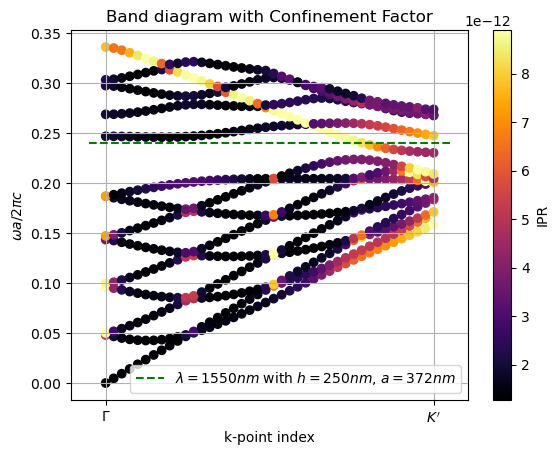

In [ ]:

def plot_confinement_factor(df):
    fig, ax = plt.subplots()
    
    # Plot each band with its confinement factor
    for b_idx in range(1, nbands+1):
        ax.scatter(df.index, df[f"te band {b_idx}"], 
                   c=df[f"Confinement Factor (b{b_idx})"], cmap='inferno', 
                 )
    
    ax.set_xlabel("k-point index")
    ax.set_ylabel("$\\omega a/2\\pi c$")
    ax.set_title("Band diagram with Confinement Factor")
    
    # Create a mappable for the colorbar using the same colormap and normalization
    norm = plt.Normalize(df[[f"Confinement Factor (b{i})" for i in range(1,nbands+1)]].min().min(),
                         df[[f"Confinement Factor (b{i})" for i in range(1,nbands+1)]].max().max())
    sm = plt.cm.ScalarMappable(cmap='inferno', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("IPR")
    plt.xticks([0,nk-1], ["$\Gamma$", "$K'$"])
    xlim = plt.xlim()
    wn = 0.24
    lam0= 1550
    ad = wn*lam0
    
  
    plt.plot(xlim, [wn, wn], "g--", label=f"$\lambda={lam0} nm$ with $h = 250 nm$, $a = {ad:.0f} nm$")
    plt.legend()
    plt.grid()

    
    


plot_confinement_factor(df)


plt.show()



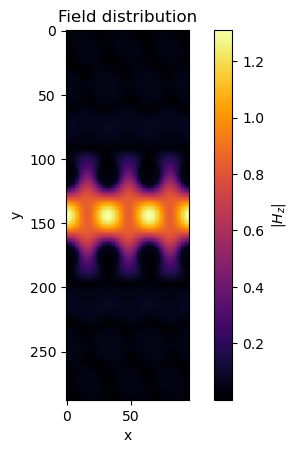

In [ ]:
field_data = simulation_line_defect.load_and_convert_field_data(30, 10, "z", "te", "h", 
                                                   conversion_options=MPBDataOptions(rectify=True, 
                                                                                     periods=(3,1,1), 
                                                                                     transpose=True),
                                                   file_comp = "z")

plt.figure()
plt.imshow(np.abs(field_data), cmap='inferno', interpolation='nearest')
plt.colorbar(label="$|H_z|$")
plt.title("Field distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.show()
